# Start

In [1]:
import pyvisa
# import numpy as np
# import time
# #import pandas as pd
# import os 
# #import matplotlib.pyplot as plt
# from lmfit.models import ExpressionModel
# from scipy.optimize import curve_fit
# import h5py
# from datetime import datetime
# import pickle

In [2]:
# %pip install lmfit

# Initialization

In [2]:
rm = pyvisa.ResourceManager()
resources = rm.list_resources()
[print(i) for i in resources]

USB0::0x0B21::0x0039::90X823743::INSTR
ASRL1::INSTR
ASRL3::INSTR
ASRL4::INSTR
ASRL5::INSTR
ASRL6::INSTR


[None, None, None, None, None, None]

In [3]:
from time import sleep
import pyvisa

# MAG_X_ADDR = "TCPIP0::169.254.82.129::7185::SOCKET"
# MAG_Y_ADDR = "TCPIP0::169.254.82.130::7185::SOCKET"
# MAG_Z_ADDR = "TCPIP0::169.254.82.131::7185::SOCKET"

# Initialising devices.
rm = pyvisa.ResourceManager()
# mag_x = rm.open_resource(
#     MAG_X_ADDR,
#     read_termination="\r\n",
#     write_termination=";",
#     timeout=100000.0,
# )
# mag_y = rm.open_resource(
#     MAG_Y_ADDR,
#     read_termination="\r\n",
#     write_termination=";",
#     timeout=100000.0,
# )
# mag_z = rm.open_resource(
#     MAG_Z_ADDR,
#     read_termination="\r\n",
#     write_termination=";",
#     timeout=100000.0,
# )
# print("Done")

In [4]:
vna=rm.open_resource('TCPIP0::192.168.111.169::inst0::INSTR')
# vna=rm.open_resource('TCPIP0::192.168.112.116::inst0::INSTR')
vna.query('*IDN?')

VisaIOError: VI_ERROR_RSRC_NFOUND (-1073807343): Insufficient location information or the requested device or resource is not present in the system.

In [35]:
yoko = rm.open_resource('USB0::0x0B21::0x0039::90X823743::INSTR')
yoko.query('*IDN?')
# vna.write(f'SENS1:BAND:RES 100Hz')
# vna.write(f'SENS1:BAND:RES 1000Hz')

'YOKOGAWA,GS210,90X823743,2.02\n'

In [7]:
vna.write(f'SENS1:SWE:POIN {5001}')

21

# low power dv1---5in 3out 50dB atten

takes 1day20h5min or 2day3h45min depending on get the single point or not

In [8]:
vna.write(f'SENS1:BAND:RES 1000Hz')

23

In [5]:
# power_list =[np.linspace(start=-31, stop=-25, num=3)] +[np.array([-34])]+ [np.array([-37,-31])]+[np.array([-1])]+[np.linspace(start=-40, stop=-28, num=5)]+[np.linspace(start=-40, stop=-22, num=7)]
# power_list =[np.linspace(start=-34, stop=-1, num=12)] + [np.linspace(start=-40, stop=-1, num=14)]*5
power_list = [0, -10]
# sweep_num0=1
# power_num0=[-7,-17,-18,-16,-15,-16]
power_list

[0, -10]

In [6]:
import numpy as np
# center_freq = np.arange(7.1, 7.5e9 + 0.001e9, 0.001e9)#[::-1] #flipped # GHz

# # center_freq=[4.096861e9,4.23702e9,4.400971e9,4.665566e9,4.826114e9,4.967191e9]
# span_freq=[1e6] #Hz

center_freq = np.arange(6e9, 8e9 + 0.01e9, 0.01e9)#[::-1] #flipped # GHz

# center_freq=[4.096861e9,4.23702e9,4.400971e9,4.665566e9,4.826114e9,4.967191e9]
span_freq=[10e6] #Hz



In [11]:
# for i,f0 in enumerate(center_freq):
#     if i<5:
#         continue
#     total=0
#     for idx_power in range(len(power_list[i])): 
#         power_target = power_list[i][idx_power]
#         sweep_num=sweep_num0*10**(-(power_target-power_num0[i])/10)
#         sweep_num=int(np.clip(round(sweep_num),1,1e4))
#         total+=sweep_num
#         print("sweep times", sweep_num)
#         print("power_target", power_target)
#     print("========================")
#     print(total)
            

In [12]:
for i,f0 in enumerate(center_freq[:]):
    vna.write(f'SENS1:FREQ:CENTER {center_freq[i]}')
    vna.write(f'SENS1:FREQ:SPAN {span_freq[0]}')
    start_freq = float(vna.query('SENS1:FREQ:START?')[:-1])
    # Query the stop frequency
    stop_freq = float(vna.query('SENS1:FREQ:STOP?')[:-1])
    # # Query the number of points
    num_points = int(vna.query('SENS1:SWE:POIN?')[:-1])
    freq = np.linspace(start_freq,stop_freq,num_points)
    for idx_power in range(len(power_list)): 
        power_target = power_list[idx_power]
        vna.write(f'SOUR:POW {power_target:.1f}')
        sweep_num=2
        ################################################################################
        print("sweep times", sweep_num)
        print("power_target", power_target)
        real_list=[]
        imag_list=[]
        for i2 in range(sweep_num):
            print(f'({i2}/{sweep_num})')
            time.sleep(7)
            vna.write('CALC1:DATA? SDATA')
            raw_data = vna.read()
            float_list = [float(x) for x in raw_data.split(',')]
            # Separate the values into two lists based on index
            column1 = np.array(float_list[0::2])  # Values at even indices (0, 2, 4, ...)
            column2 = np.array(float_list[1::2])  # Values at odd indices (1, 3, 5, ...)
            real_list.append(column1)
            imag_list.append(column2)
        with open(f's21_sweep_power_{power_target}_freq_{f0}_avg_{sweep_num}'+datetime.now().strftime("_%y%m%d-%H%M%S")+'.pkl','wb') as f:
            pickle.dump({
                "freq":freq,
                'real_list':real_list,
                'imag_list':imag_list,
                'atten':0,
                },f)
            

sweep times 2
power_target 0
(0/2)


KeyboardInterrupt: 

In [ ]:
jfgawoigtfwoi
#only run below if time is enough!!!

NameError: name 'jfgawoigtfwoi' is not defined

In [ ]:
power_list = [np.linspace(start=-40, stop=-2, num=1)]
sweep_num0=1
power_num0=[-37]
power_list

[array([-40.])]

In [ ]:
center_freq=[4.967191e9]#4.789612620e9,
span_freq=[20e3]#70e3,

7h39min for this point!!!

In [ ]:
for i,f0 in enumerate(center_freq):
    for idx_power in range(len(power_list[i])): 
        power_target = power_list[i][idx_power]
        sweep_num=sweep_num0*10**(-(power_target-power_num0[i])/10)
        sweep_num=int(np.clip(round(sweep_num),1,1e3))
        print("sweep times", sweep_num)
        print("power_target", power_target)

sweep times 2
power_target -40.0


In [ ]:
for temmm in range(500):
    for i,f0 in enumerate(center_freq):
        vna.write(f'SENS1:FREQ:CENTER {center_freq[i]}')
        vna.write(f'SENS1:FREQ:SPAN {span_freq[i]}')
        start_freq = float(vna.query('SENS1:FREQ:START?')[:-1])
        # Query the stop frequency
        stop_freq = float(vna.query('SENS1:FREQ:STOP?')[:-1])
        # # Query the number of points
        num_points = int(vna.query('SENS1:SWE:POIN?')[:-1])
        freq = np.linspace(start_freq,stop_freq,num_points)
        for idx_power in range(len(power_list[i])): 
            power_target = power_list[i][idx_power]
            vna.write(f'SOUR:POW {power_target:.1f}')
            sweep_num=sweep_num0*10**(-(power_target-power_num0[i])/10)
            sweep_num=int(np.clip(round(sweep_num),1,1000))
            print("sweep times", sweep_num)
            print("power_target", power_target)
            real_list=[]
            imag_list=[]
            for i2 in range(sweep_num):
                print(f'({i2}/{sweep_num})')
                time.sleep(55)
                vna.write('CALC1:DATA? SDATA')
                raw_data = vna.read()
                float_list = [float(x) for x in raw_data.split(',')]
                # Separate the values into two lists based on index
                column1 = np.array(float_list[0::2])  # Values at even indices (0, 2, 4, ...)
                column2 = np.array(float_list[1::2])  # Values at odd indices (1, 3, 5, ...)
                real_list.append(column1)
                imag_list.append(column2)
            with open(f's21_sweep_power_{power_target}_freq_{f0}_avg_{sweep_num}'+datetime.now().strftime("_%y%m%d-%H%M%S")+'.pkl','wb') as f:
                pickle.dump({
                    "freq":freq,
                    'real_list':real_list,
                    'imag_list':imag_list,
                    'atten':50,
                    },f)

sweep times 2
power_target -40.0
(0/2)
(1/2)
sweep times 2
power_target -40.0
(0/2)
(1/2)
sweep times 2
power_target -40.0
(0/2)
(1/2)
sweep times 2
power_target -40.0
(0/2)
(1/2)
sweep times 2
power_target -40.0
(0/2)
(1/2)
sweep times 2
power_target -40.0
(0/2)
(1/2)
sweep times 2
power_target -40.0
(0/2)
(1/2)
sweep times 2
power_target -40.0
(0/2)
(1/2)
sweep times 2
power_target -40.0
(0/2)
(1/2)


VisaIOError: VI_ERROR_TMO (-1073807339): Timeout expired before operation completed.

In [ ]:
jfgawoigtfwoi
change line

# low power dv2---9in 1out 50dB atten

takes 11.3h or 20h depending on choose long or short version

In [ ]:
vna.write(f'SENS1:BAND:RES 10Hz')

21

In [ ]:
power_list =[np.linspace(start=-40, stop=-1, num=14)]*6
# power_list =[np.linspace(start=-34, stop=-1, num=12)] + [np.linspace(start=-40, stop=-1, num=14)]*5
sweep_num0=1
# power_num0=[-23,-23,-20,-23,-23,-23] #short version,11.3h
power_num0=[-21.5,-23,-20,-23,-23,-21.5] #short version, 12.5h
# power_num0=[-20,-23,-20,-23,-23,-20] #long version, 14.35h
power_list

[array([-40., -37., -34., -31., -28., -25., -22., -19., -16., -13., -10.,
         -7.,  -4.,  -1.]),
 array([-40., -37., -34., -31., -28., -25., -22., -19., -16., -13., -10.,
         -7.,  -4.,  -1.]),
 array([-40., -37., -34., -31., -28., -25., -22., -19., -16., -13., -10.,
         -7.,  -4.,  -1.]),
 array([-40., -37., -34., -31., -28., -25., -22., -19., -16., -13., -10.,
         -7.,  -4.,  -1.]),
 array([-40., -37., -34., -31., -28., -25., -22., -19., -16., -13., -10.,
         -7.,  -4.,  -1.]),
 array([-40., -37., -34., -31., -28., -25., -22., -19., -16., -13., -10.,
         -7.,  -4.,  -1.])]

In [ ]:
center_freq=[4.396467e9,4.460386e9,4.535656e9,4.649386e9,4.804364e9,4.969118e9]
span_freq=[20e3,20e3,20e3,25e3,20e3,20e3]


In [ ]:
for i,f0 in enumerate(center_freq):
    total=0
    for idx_power in range(len(power_list[i])): 
        power_target = power_list[i][idx_power]
        sweep_num=sweep_num0*10**(-(power_target-power_num0[i])/10)
        sweep_num=int(np.clip(round(sweep_num),1,1e4))
        total+=sweep_num
        print("sweep times", sweep_num)
        print("power_target", power_target)
    print("========================")
    print(total)
            

sweep times 71
power_target -40.0
sweep times 35
power_target -37.0
sweep times 18
power_target -34.0
sweep times 9
power_target -31.0
sweep times 4
power_target -28.0
sweep times 2
power_target -25.0
sweep times 1
power_target -22.0
sweep times 1
power_target -19.0
sweep times 1
power_target -16.0
sweep times 1
power_target -13.0
sweep times 1
power_target -10.0
sweep times 1
power_target -7.0
sweep times 1
power_target -4.0
sweep times 1
power_target -1.0
147
sweep times 50
power_target -40.0
sweep times 25
power_target -37.0
sweep times 13
power_target -34.0
sweep times 6
power_target -31.0
sweep times 3
power_target -28.0
sweep times 2
power_target -25.0
sweep times 1
power_target -22.0
sweep times 1
power_target -19.0
sweep times 1
power_target -16.0
sweep times 1
power_target -13.0
sweep times 1
power_target -10.0
sweep times 1
power_target -7.0
sweep times 1
power_target -4.0
sweep times 1
power_target -1.0
107
sweep times 100
power_target -40.0
sweep times 50
power_target -37.0

In [ ]:
for i,f0 in enumerate(center_freq):
    vna.write(f'SENS1:FREQ:CENTER {center_freq[i]}')
    vna.write(f'SENS1:FREQ:SPAN {span_freq[i]}')
    start_freq = float(vna.query('SENS1:FREQ:START?')[:-1])
    # Query the stop frequency
    stop_freq = float(vna.query('SENS1:FREQ:STOP?')[:-1])
    # # Query the number of points
    num_points = int(vna.query('SENS1:SWE:POIN?')[:-1])
    freq = np.linspace(start_freq,stop_freq,num_points)
    for idx_power in range(len(power_list[i])): 
        power_target = power_list[i][idx_power]
        vna.write(f'SOUR:POW {power_target:.1f}')
        sweep_num=sweep_num0*10**(-(power_target-power_num0[i])/10)
        sweep_num=int(np.clip(round(sweep_num),1,10000))
        print("sweep times", sweep_num)
        print("power_target", power_target)
        real_list=[]
        imag_list=[]
        for i2 in range(sweep_num):
            print(f'({i2}/{sweep_num})')
            time.sleep(55)
            vna.write('CALC1:DATA? SDATA')
            raw_data = vna.read()
            float_list = [float(x) for x in raw_data.split(',')]
            # Separate the values into two lists based on index
            column1 = np.array(float_list[0::2])  # Values at even indices (0, 2, 4, ...)
            column2 = np.array(float_list[1::2])  # Values at odd indices (1, 3, 5, ...)
            real_list.append(column1)
            imag_list.append(column2)
        with open(f's21_sweep_power_{power_target}_freq_{f0}_avg_{sweep_num}'+datetime.now().strftime("_%y%m%d-%H%M%S")+'.pkl','wb') as f:
            pickle.dump({
                "freq":freq,
                'real_list':real_list,
                'imag_list':imag_list,
                'atten':50,
                },f)
            

sweep times 71
power_target -40.0
(0/71)
(1/71)
(2/71)
(3/71)
(4/71)
(5/71)
(6/71)
(7/71)
(8/71)
(9/71)
(10/71)
(11/71)
(12/71)
(13/71)
(14/71)
(15/71)
(16/71)
(17/71)
(18/71)
(19/71)
(20/71)
(21/71)
(22/71)
(23/71)
(24/71)
(25/71)
(26/71)
(27/71)
(28/71)
(29/71)
(30/71)
(31/71)
(32/71)
(33/71)
(34/71)
(35/71)
(36/71)
(37/71)
(38/71)
(39/71)
(40/71)
(41/71)
(42/71)
(43/71)
(44/71)
(45/71)
(46/71)
(47/71)
(48/71)
(49/71)
(50/71)
(51/71)
(52/71)
(53/71)
(54/71)
(55/71)
(56/71)
(57/71)
(58/71)
(59/71)
(60/71)
(61/71)
(62/71)
(63/71)
(64/71)
(65/71)
(66/71)
(67/71)
(68/71)
(69/71)
(70/71)
sweep times 35
power_target -37.0
(0/35)
(1/35)
(2/35)
(3/35)
(4/35)
(5/35)
(6/35)
(7/35)
(8/35)
(9/35)
(10/35)
(11/35)
(12/35)
(13/35)
(14/35)
(15/35)
(16/35)
(17/35)
(18/35)
(19/35)
(20/35)
(21/35)
(22/35)
(23/35)
(24/35)
(25/35)
(26/35)
(27/35)
(28/35)
(29/35)
(30/35)
(31/35)
(32/35)
(33/35)
(34/35)
sweep times 18
power_target -34.0
(0/18)
(1/18)
(2/18)
(3/18)
(4/18)
(5/18)
(6/18)
(7/18)
(8/18)
(9/18)


In [ ]:
for i,f0 in enumerate(center_freq):
    vna.write(f'SENS1:FREQ:CENTER {center_freq[i]}')
    vna.write(f'SENS1:FREQ:SPAN {span_freq[i]}')
    start_freq = float(vna.query('SENS1:FREQ:START?')[:-1])
    # Query the stop frequency
    stop_freq = float(vna.query('SENS1:FREQ:STOP?')[:-1])
    # # Query the number of points
    num_points = int(vna.query('SENS1:SWE:POIN?')[:-1])
    freq = np.linspace(start_freq,stop_freq,num_points)
    for idx_power in range(len(power_list[i])): 
        power_target = power_list[i][idx_power]
        vna.write(f'SOUR:POW {power_target:.1f}')
        sweep_num=sweep_num0*10**(-(power_target-power_num0[i])/10)
        sweep_num=int(np.clip(round(sweep_num),1,10000))
        print("sweep times", sweep_num)
        print("power_target", power_target)
        real_list=[]
        imag_list=[]
        for i2 in range(sweep_num):
            print(f'({i2}/{sweep_num})')
            time.sleep(55)
            vna.write('CALC1:DATA? SDATA')
            raw_data = vna.read()
            float_list = [float(x) for x in raw_data.split(',')]
            # Separate the values into two lists based on index
            column1 = np.array(float_list[0::2])  # Values at even indices (0, 2, 4, ...)
            column2 = np.array(float_list[1::2])  # Values at odd indices (1, 3, 5, ...)
            real_list.append(column1)
            imag_list.append(column2)
        with open(f's21_sweep_power_{power_target}_freq_{f0}_avg_{sweep_num}'+datetime.now().strftime("_%y%m%d-%H%M%S")+'.pkl','wb') as f:
            pickle.dump({
                "freq":freq,
                'real_list':real_list,
                'imag_list':imag_list,
                'atten':50,
                },f)
            

sweep times 447
power_target -32.5
(0/447)
(1/447)
(2/447)
(3/447)
(4/447)
(5/447)
(6/447)
(7/447)
(8/447)
(9/447)
(10/447)
(11/447)
(12/447)
(13/447)
(14/447)
(15/447)
(16/447)
(17/447)
(18/447)
(19/447)
(20/447)
(21/447)
(22/447)
(23/447)
(24/447)
(25/447)
(26/447)
(27/447)
(28/447)
(29/447)
(30/447)
(31/447)
(32/447)
(33/447)
(34/447)
(35/447)
(36/447)
(37/447)
(38/447)
(39/447)
(40/447)
(41/447)
(42/447)
(43/447)
(44/447)
(45/447)
(46/447)
(47/447)
(48/447)
(49/447)
(50/447)
(51/447)
(52/447)
(53/447)
(54/447)
(55/447)
(56/447)
(57/447)
(58/447)
(59/447)
(60/447)
(61/447)
(62/447)
(63/447)
(64/447)
(65/447)
(66/447)
(67/447)
(68/447)
(69/447)
(70/447)
(71/447)
(72/447)
(73/447)
(74/447)
(75/447)
(76/447)
(77/447)
(78/447)
(79/447)
(80/447)
(81/447)
(82/447)
(83/447)
(84/447)
(85/447)
(86/447)
(87/447)
(88/447)
(89/447)
(90/447)
(91/447)
(92/447)
(93/447)
(94/447)
(95/447)
(96/447)
(97/447)
(98/447)
(99/447)
(100/447)
(101/447)
(102/447)
(103/447)
(104/447)
(105/447)
(106/447)
(107/

In [ ]:
vna.write(f'SENS1:BAND:RES 100Hz')

22

In [ ]:
power_list = [np.linspace(start=-39, stop=0, num=14)] #np.linspace(start=-50, stop=-35, num=4),
sweep_num0=2
power_num0=[-39]#-22,
power_list

[array([-39., -36., -33., -30., -27., -24., -21., -18., -15., -12.,  -9.,
         -6.,  -3.,   0.])]

In [ ]:
center_freq=[4.63959088e9]#4.789612620e9,
span_freq=[40e3]#70e3,

In [ ]:
for i,f0 in enumerate(center_freq):
    for idx_power in range(len(power_list[i])): 
        power_target = power_list[i][idx_power]
        sweep_num=sweep_num0*10**(-(power_target-power_num0[i])/10)
        sweep_num=int(np.clip(round(sweep_num),1,1e3))
        print("sweep times", sweep_num)
        print("power_target", power_target)

sweep times 2
power_target -39.0
sweep times 1
power_target -36.0
sweep times 1
power_target -33.0
sweep times 1
power_target -30.0
sweep times 1
power_target -27.0
sweep times 1
power_target -24.0
sweep times 1
power_target -21.0
sweep times 1
power_target -18.0
sweep times 1
power_target -15.0
sweep times 1
power_target -12.0
sweep times 1
power_target -9.0
sweep times 1
power_target -6.0
sweep times 1
power_target -3.0
sweep times 1
power_target 0.0


In [ ]:
for i,f0 in enumerate(center_freq):
    vna.write(f'SENS1:FREQ:CENTER {center_freq[i]}')
    vna.write(f'SENS1:FREQ:SPAN {span_freq[i]}')
    start_freq = float(vna.query('SENS1:FREQ:START?')[:-1])
    # Query the stop frequency
    stop_freq = float(vna.query('SENS1:FREQ:STOP?')[:-1])
    # # Query the number of points
    num_points = int(vna.query('SENS1:SWE:POIN?')[:-1])
    freq = np.linspace(start_freq,stop_freq,num_points)
    for idx_power in range(len(power_list[i])): 
        power_target = power_list[i][idx_power]
        vna.write(f'SOUR:POW {power_target:.1f}')
        sweep_num=sweep_num0*10**(-(power_target-power_num0[i])/10)
        sweep_num=int(np.clip(round(sweep_num),1,1000))
        print("sweep times", sweep_num)
        print("power_target", power_target)
        real_list=[]
        imag_list=[]
        for i2 in range(sweep_num):
            print(f'({i2}/{sweep_num})')
            time.sleep(10)
            vna.write('CALC1:DATA? SDATA')
            raw_data = vna.read()
            float_list = [float(x) for x in raw_data.split(',')]
            # Separate the values into two lists based on index
            column1 = np.array(float_list[0::2])  # Values at even indices (0, 2, 4, ...)
            column2 = np.array(float_list[1::2])  # Values at odd indices (1, 3, 5, ...)
            real_list.append(column1)
            imag_list.append(column2)
        with open(f's21_sweep_power_{power_target}_freq_{f0}_avg_{sweep_num}'+datetime.now().strftime("_%y%m%d-%H%M%S")+'.pkl','wb') as f:
            pickle.dump({
                "freq":freq,
                'real_list':real_list,
                'imag_list':imag_list,
                'atten':50,
                },f)

sweep times 2
power_target -39.0
(0/2)
(1/2)
sweep times 1
power_target -36.0
(0/1)
sweep times 1
power_target -33.0
(0/1)
sweep times 1
power_target -30.0
(0/1)
sweep times 1
power_target -27.0
(0/1)
sweep times 1
power_target -24.0
(0/1)
sweep times 1
power_target -21.0
(0/1)
sweep times 1
power_target -18.0
(0/1)
sweep times 1
power_target -15.0
(0/1)
sweep times 1
power_target -12.0
(0/1)
sweep times 1
power_target -9.0
(0/1)
sweep times 1
power_target -6.0
(0/1)
sweep times 1
power_target -3.0
(0/1)
sweep times 1
power_target 0.0
(0/1)


# high power dv1---5in 3out 0dB atten run this for YS

43min

In [ ]:
vna.write(f'SENS1:BAND:RES 2kHz') #run this

21

In [ ]:
vna.write(f'SENS1:SWE:POIN {1001}')

21

In [ ]:
power_list = [np.linspace(start=-39, stop=0, num=14)]*6
# power_list =[np.linspace(start=-34, stop=-1, num=12)] + [np.linspace(start=-40, stop=-1, num=14)]*5
sweep_num0=1024
power_num0=[-44]+[-39]*5
power_list


# +3db power, point/2

[array([-39., -36., -33., -30., -27., -24., -21., -18., -15., -12.,  -9.,
         -6.,  -3.,   0.]),
 array([-39., -36., -33., -30., -27., -24., -21., -18., -15., -12.,  -9.,
         -6.,  -3.,   0.]),
 array([-39., -36., -33., -30., -27., -24., -21., -18., -15., -12.,  -9.,
         -6.,  -3.,   0.]),
 array([-39., -36., -33., -30., -27., -24., -21., -18., -15., -12.,  -9.,
         -6.,  -3.,   0.]),
 array([-39., -36., -33., -30., -27., -24., -21., -18., -15., -12.,  -9.,
         -6.,  -3.,   0.]),
 array([-39., -36., -33., -30., -27., -24., -21., -18., -15., -12.,  -9.,
         -6.,  -3.,   0.])]

In [ ]:
center_freq=[4.096832e9,4.237008e9,4.40096e9,4.66555e9,4.826096e9,4.96716e9]
span_freq=[25e3,10e3,20e3,25e3,20e3,20e3]


In [ ]:
for i,f0 in enumerate(center_freq):
    total=0
    for idx_power in range(len(power_list[i])): 
        power_target = power_list[i][idx_power]
        sweep_num=sweep_num0*10**(-(power_target-power_num0[i])/10)
        sweep_num=int(np.clip(round(sweep_num),1,1e4))
        total+=sweep_num
        print("sweep times", sweep_num)
        print("power_target", power_target)
    print("========================")
    print(total)
            

sweep times 324
power_target -39.0
sweep times 162
power_target -36.0
sweep times 81
power_target -33.0
sweep times 41
power_target -30.0
sweep times 20
power_target -27.0
sweep times 10
power_target -24.0
sweep times 5
power_target -21.0
sweep times 3
power_target -18.0
sweep times 1
power_target -15.0
sweep times 1
power_target -12.0
sweep times 1
power_target -9.0
sweep times 1
power_target -6.0
sweep times 1
power_target -3.0
sweep times 1
power_target 0.0
652
sweep times 1024
power_target -39.0
sweep times 513
power_target -36.0
sweep times 257
power_target -33.0
sweep times 129
power_target -30.0
sweep times 65
power_target -27.0
sweep times 32
power_target -24.0
sweep times 16
power_target -21.0
sweep times 8
power_target -18.0
sweep times 4
power_target -15.0
sweep times 2
power_target -12.0
sweep times 1
power_target -9.0
sweep times 1
power_target -6.0
sweep times 1
power_target -3.0
sweep times 1
power_target 0.0
2054
sweep times 1024
power_target -39.0
sweep times 513
power

In [ ]:
for i,f0 in enumerate(center_freq):
    vna.write(f'SENS1:FREQ:CENTER {center_freq[i]}')
    vna.write(f'SENS1:FREQ:SPAN {span_freq[i]}')
    start_freq = float(vna.query('SENS1:FREQ:START?')[:-1])
    # Query the stop frequency
    stop_freq = float(vna.query('SENS1:FREQ:STOP?')[:-1])
    # # Query the number of points
    num_points = int(vna.query('SENS1:SWE:POIN?')[:-1])
    freq = np.linspace(start_freq,stop_freq,num_points)
    for idx_power in range(len(power_list[i])): 
        power_target = power_list[i][idx_power]
        vna.write(f'SOUR:POW {power_target:.1f}')
        sweep_num=sweep_num0*10**(-(power_target-power_num0[i])/10)
        sweep_num=int(np.clip(round(sweep_num),1,10000))
        print("sweep times", sweep_num)
        print("power_target", power_target)
        real_list=[]
        imag_list=[]
        for i2 in range(sweep_num):
            print(f'({i2}/{sweep_num})')
            time.sleep(1)
            vna.write('CALC1:DATA? SDATA')
            raw_data = vna.read()
            float_list = [float(x) for x in raw_data.split(',')]
            # Separate the values into two lists based on index
            column1 = np.array(float_list[0::2])  # Values at even indices (0, 2, 4, ...)
            column2 = np.array(float_list[1::2])  # Values at odd indices (1, 3, 5, ...)
            real_list.append(column1)
            imag_list.append(column2)
        with open(f's21_sweep_power_{power_target}_freq_{f0}_avg_{sweep_num}'+datetime.now().strftime("_%y%m%d-%H%M%S")+'.pkl','wb') as f:
            pickle.dump({
                "freq":freq,
                'real_list':real_list,
                'imag_list':imag_list,
                'atten':0,
                },f)
            

sweep times 324
power_target -39.0
(0/324)
(1/324)
(2/324)
(3/324)
(4/324)
(5/324)
(6/324)
(7/324)
(8/324)
(9/324)
(10/324)
(11/324)
(12/324)
(13/324)
(14/324)
(15/324)
(16/324)
(17/324)
(18/324)
(19/324)
(20/324)
(21/324)
(22/324)
(23/324)
(24/324)
(25/324)
(26/324)
(27/324)
(28/324)
(29/324)
(30/324)
(31/324)
(32/324)
(33/324)
(34/324)
(35/324)
(36/324)
(37/324)
(38/324)
(39/324)
(40/324)
(41/324)
(42/324)
(43/324)
(44/324)
(45/324)
(46/324)
(47/324)
(48/324)
(49/324)
(50/324)
(51/324)
(52/324)
(53/324)
(54/324)
(55/324)
(56/324)
(57/324)
(58/324)
(59/324)
(60/324)
(61/324)
(62/324)
(63/324)
(64/324)
(65/324)
(66/324)
(67/324)
(68/324)
(69/324)
(70/324)
(71/324)
(72/324)
(73/324)
(74/324)
(75/324)
(76/324)
(77/324)
(78/324)
(79/324)
(80/324)
(81/324)
(82/324)
(83/324)
(84/324)
(85/324)
(86/324)
(87/324)
(88/324)
(89/324)
(90/324)
(91/324)
(92/324)
(93/324)
(94/324)
(95/324)
(96/324)
(97/324)
(98/324)
(99/324)
(100/324)
(101/324)
(102/324)
(103/324)
(104/324)
(105/324)
(106/324)
(107/

# high power dv2---9in 1out 10dB atten

12min

In [ ]:
vna.write(f'SENS1:BAND:RES 5kHz')

22

In [ ]:
power_list = [np.linspace(start=-22, stop=0, num=12)]*6
# power_list =[np.linspace(start=-34, stop=-1, num=12)] + [np.linspace(start=-40, stop=-1, num=14)]*5
sweep_num0=1
power_num0=[-49]*6 #short version, 12.5h
power_list

[array([-22., -20., -18., -16., -14., -12., -10.,  -8.,  -6.,  -4.,  -2.,
          0.]),
 array([-22., -20., -18., -16., -14., -12., -10.,  -8.,  -6.,  -4.,  -2.,
          0.]),
 array([-22., -20., -18., -16., -14., -12., -10.,  -8.,  -6.,  -4.,  -2.,
          0.]),
 array([-22., -20., -18., -16., -14., -12., -10.,  -8.,  -6.,  -4.,  -2.,
          0.]),
 array([-22., -20., -18., -16., -14., -12., -10.,  -8.,  -6.,  -4.,  -2.,
          0.]),
 array([-22., -20., -18., -16., -14., -12., -10.,  -8.,  -6.,  -4.,  -2.,
          0.])]

In [ ]:
center_freq=[4.396467e9,4.460386e9,4.535656e9,4.649386e9,4.804364e9,4.969118e9]
span_freq=[20e3,20e3,20e3,25e3,20e3,20e3]


In [ ]:
for i,f0 in enumerate(center_freq):
    total=0
    for idx_power in range(len(power_list[i])): 
        power_target = power_list[i][idx_power]
        sweep_num=sweep_num0*10**(-(power_target-power_num0[i])/10)
        sweep_num=int(np.clip(round(sweep_num),1,1e4))
        total+=sweep_num
        print("sweep times", sweep_num)
        print("power_target", power_target)
    print("========================")
    print(total)
            

sweep times 1
power_target -22.0
sweep times 1
power_target -20.0
sweep times 1
power_target -18.0
sweep times 1
power_target -16.0
sweep times 1
power_target -14.0
sweep times 1
power_target -12.0
sweep times 1
power_target -10.0
sweep times 1
power_target -8.0
sweep times 1
power_target -6.0
sweep times 1
power_target -4.0
sweep times 1
power_target -2.0
sweep times 1
power_target 0.0
12
sweep times 1
power_target -22.0
sweep times 1
power_target -20.0
sweep times 1
power_target -18.0
sweep times 1
power_target -16.0
sweep times 1
power_target -14.0
sweep times 1
power_target -12.0
sweep times 1
power_target -10.0
sweep times 1
power_target -8.0
sweep times 1
power_target -6.0
sweep times 1
power_target -4.0
sweep times 1
power_target -2.0
sweep times 1
power_target 0.0
12
sweep times 1
power_target -22.0
sweep times 1
power_target -20.0
sweep times 1
power_target -18.0
sweep times 1
power_target -16.0
sweep times 1
power_target -14.0
sweep times 1
power_target -12.0
sweep times 1
po

In [ ]:
for i,f0 in enumerate(center_freq):
    vna.write(f'SENS1:FREQ:CENTER {center_freq[i]}')
    vna.write(f'SENS1:FREQ:SPAN {span_freq[i]}')
    start_freq = float(vna.query('SENS1:FREQ:START?')[:-1])
    # Query the stop frequency
    stop_freq = float(vna.query('SENS1:FREQ:STOP?')[:-1])
    # # Query the number of points
    num_points = int(vna.query('SENS1:SWE:POIN?')[:-1])
    freq = np.linspace(start_freq,stop_freq,num_points)
    for idx_power in range(len(power_list[i])): 
        power_target = power_list[i][idx_power]
        vna.write(f'SOUR:POW {power_target:.1f}')
        sweep_num=sweep_num0*10**(-(power_target-power_num0[i])/10)
        sweep_num=int(np.clip(round(sweep_num),1,10000))
        print("sweep times", sweep_num)
        print("power_target", power_target)
        real_list=[]
        imag_list=[]
        for i2 in range(sweep_num):
            print(f'({i2}/{sweep_num})')
            time.sleep(0.5)
            vna.write('CALC1:DATA? SDATA')
            raw_data = vna.read()
            float_list = [float(x) for x in raw_data.split(',')]
            # Separate the values into two lists based on index
            column1 = np.array(float_list[0::2])  # Values at even indices (0, 2, 4, ...)
            column2 = np.array(float_list[1::2])  # Values at odd indices (1, 3, 5, ...)
            real_list.append(column1)
            imag_list.append(column2)
        with open(f's21_sweep_power_{power_target}_freq_{f0}_avg_{sweep_num}'+datetime.now().strftime("_%y%m%d-%H%M%S")+'.pkl','wb') as f:
            pickle.dump({
                "freq":freq,
                'real_list':real_list,
                'imag_list':imag_list,
                'atten':0,
                },f)
            

sweep times 1
power_target -22.0
(0/1)
sweep times 1
power_target -20.0
(0/1)
sweep times 1
power_target -18.0
(0/1)
sweep times 1
power_target -16.0
(0/1)
sweep times 1
power_target -14.0
(0/1)
sweep times 1
power_target -12.0
(0/1)
sweep times 1
power_target -10.0
(0/1)
sweep times 1
power_target -8.0
(0/1)
sweep times 1
power_target -6.0
(0/1)
sweep times 1
power_target -4.0
(0/1)
sweep times 1
power_target -2.0
(0/1)
sweep times 1
power_target 0.0
(0/1)
sweep times 1
power_target -22.0
(0/1)
sweep times 1
power_target -20.0
(0/1)
sweep times 1
power_target -18.0
(0/1)
sweep times 1
power_target -16.0
(0/1)
sweep times 1
power_target -14.0
(0/1)
sweep times 1
power_target -12.0
(0/1)
sweep times 1
power_target -10.0
(0/1)
sweep times 1
power_target -8.0
(0/1)
sweep times 1
power_target -6.0
(0/1)
sweep times 1
power_target -4.0
(0/1)
sweep times 1
power_target -2.0
(0/1)
sweep times 1
power_target 0.0
(0/1)
sweep times 1
power_target -22.0
(0/1)
sweep times 1
power_target -20.0
(0/1

# DC sweep


In [ ]:
lev=-1
dc_stop = 1
step_size = 2.5e-2
dc_list =np.arange(lev,dc_stop, step_size)
dc_list,dc_list.shape

(array([-1.0000000e+00, -9.7500000e-01, -9.5000000e-01, -9.2500000e-01,
        -9.0000000e-01, -8.7500000e-01, -8.5000000e-01, -8.2500000e-01,
        -8.0000000e-01, -7.7500000e-01, -7.5000000e-01, -7.2500000e-01,
        -7.0000000e-01, -6.7500000e-01, -6.5000000e-01, -6.2500000e-01,
        -6.0000000e-01, -5.7500000e-01, -5.5000000e-01, -5.2500000e-01,
        -5.0000000e-01, -4.7500000e-01, -4.5000000e-01, -4.2500000e-01,
        -4.0000000e-01, -3.7500000e-01, -3.5000000e-01, -3.2500000e-01,
        -3.0000000e-01, -2.7500000e-01, -2.5000000e-01, -2.2500000e-01,
        -2.0000000e-01, -1.7500000e-01, -1.5000000e-01, -1.2500000e-01,
        -1.0000000e-01, -7.5000000e-02, -5.0000000e-02, -2.5000000e-02,
         8.8817842e-16,  2.5000000e-02,  5.0000000e-02,  7.5000000e-02,
         1.0000000e-01,  1.2500000e-01,  1.5000000e-01,  1.7500000e-01,
         2.0000000e-01,  2.2500000e-01,  2.5000000e-01,  2.7500000e-01,
         3.0000000e-01,  3.2500000e-01,  3.5000000e-01,  3.75000

In [ ]:
lev=-5e-3
dc_stop = 5e-3
step_size = 0.1e-3
dc_list =np.arange(lev,dc_stop, step_size)
small_step = 0.1e-3

curr_val = float(dc0.query("SOUR:LEV?"))
#Configure yokogawa at certain current
if curr_val < lev:
    n_steps = int(np.abs(curr_val - lev)/small_step)
    for ii in range(n_steps):
        new_curr = curr_val+ (ii+1)*small_step
        dc0.write(":SOUR:LEV %.10f" % (new_curr))
        time.sleep(0.1)
if curr_val> lev:
    n_steps = int(np.abs(curr_val - lev)/small_step)
    for ii in range(n_steps):
        new_curr = curr_val- (ii+1)*small_step
        dc0.write(":SOUR:LEV %.10f" % (new_curr))
        time.sleep(0.1)
        
print(dc0.query("SOUR:LEV?"))
print('Step 1 passed')

-4.9000E-3

Step 1 passed


In [ ]:
z1 = []
# dc_list=np.linspace(-5e-3, 5E-3, 51)

for dc in dc_list:
    print(dc)
    start_time=time.time()
    curr_val = float(dc0.query("SOUR:LEV?"))
    n_steps = int(np.abs(dc - curr_val)/small_step)
    new_val = curr_val
    while new_val < dc:
        dc0.write(":SOUR:LEV %.10f" % (new_val))
        new_val += small_step
        time.sleep(0.1)

    dc0.query(":SOUR:LEV?")
    # time.sleep()
    
    df = read_trace(0.8, None,None, fit=True)
    
    df.to_csv(f'VNA_data\\JPA_DC_sweep_20251118\\JPA_freq_vs_dcbias_{dc*1E3:.3f}mV_B_0mT_voltage_mode_-120dBm_1001pts_VNABW2KHz_2.csv')
    time.sleep(0.1)
    freq=df['freq']
    z1.append(df["z"])

-0.005
-0.0049
-0.0048
-0.004699999999999999
-0.004599999999999999
-0.004499999999999999
-0.0043999999999999985
-0.004299999999999998
-0.004199999999999998
-0.004099999999999998
-0.0039999999999999975
-0.0038999999999999972
-0.003799999999999997
-0.0036999999999999967
-0.0035999999999999964
-0.003499999999999996
-0.003399999999999996
-0.0032999999999999956
-0.0031999999999999954
-0.003099999999999995
-0.002999999999999995
-0.0028999999999999946
-0.0027999999999999943
-0.002699999999999994
-0.002599999999999994
-0.0024999999999999935
-0.0023999999999999933
-0.002299999999999993
-0.0021999999999999928
-0.0020999999999999925
-0.0019999999999999922
-0.001899999999999992
-0.0017999999999999917
-0.0016999999999999914
-0.0015999999999999912
-0.001499999999999991
-0.0013999999999999907
-0.0012999999999999904
-0.0011999999999999901
-0.0010999999999999899
-0.0009999999999999896
-0.0008999999999999894
-0.0007999999999999891
-0.0006999999999999888
-0.0005999999999999886
-0.0004999999999999883
-0.0

## plot data

In [ ]:
df2=[]

lev=-5e-3
dc_stop = 5e-3
step_size = 0.1e-3
dc_list =np.arange(lev,dc_stop, step_size)

for dc in dc_list[:]:
    df2.append(pd.read_csv(f'Z:\\MW measurement\\20251107_cooldown\\VNA_data\\JPA_DC_sweep_20251118\\JPA_freq_vs_dcbias_{dc*1E3:.3f}mV_B_400mT_voltage_mode_-120dBm_1001pts_VNABW2KHz.csv', dtype={'freq':'float64'}, converters={'z':lambda x:complex(x.replace('i', 'j'))}))

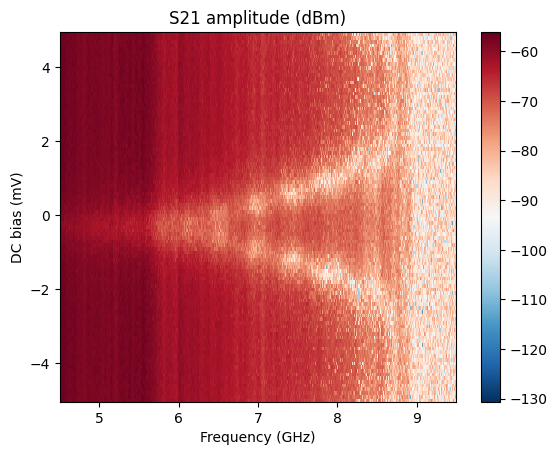

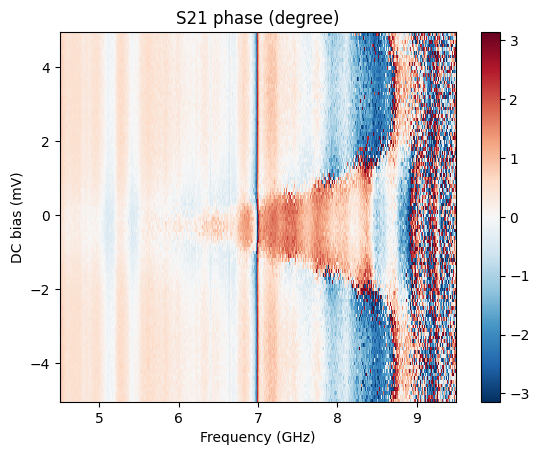

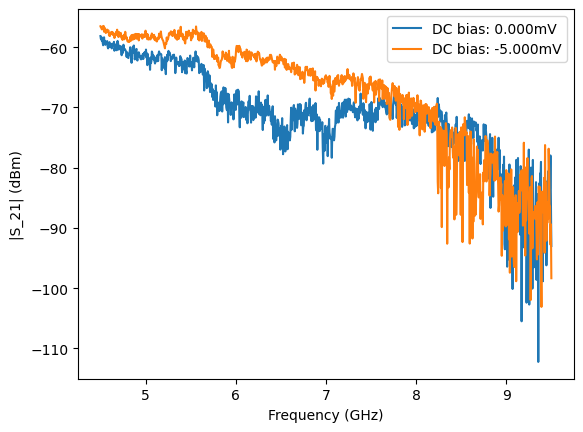

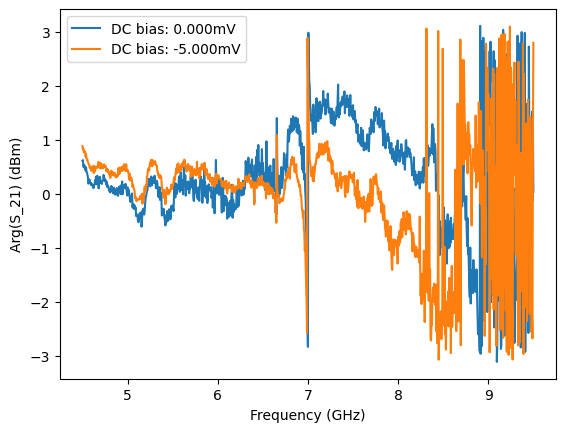

In [ ]:
%matplotlib inline
# dc_list=dc_list[10:-10]
data=[]
for i,dc in enumerate(dc_list):
    data.append(df2[i]["z"])
data=np.array(data)

# %matplotlib inline
plt.figure()
plt.pcolor( df2[0]["freq"]/1e9, dc_list*1e3, 20*np.log10(np.abs( data ) ), cmap="RdBu_r")
plt.colorbar()
plt.xlabel("Frequency (GHz)")
plt.ylabel("DC bias (mV)")
plt.title("S21 amplitude (dBm)")

plt.figure()
plt.pcolor( df2[0]["freq"]/1e9, dc_list*1e3,  (np.angle( data)) , cmap="RdBu_r" )
plt.colorbar()
plt.xlabel("Frequency (GHz)")
plt.ylabel("DC bias (mV)")
plt.title("S21 phase (degree)")


plt.figure()
idx=50
plt.plot( df2[0]["freq"]/1e9, 20*np.log10(np.abs( data[idx] ) ) ,label=f"DC bias: {dc_list[idx]*1e3:.3f}mV")
idx=0
plt.plot( df2[0]["freq"]/1e9, 20*np.log10(np.abs( data[idx] ) ) ,label=f"DC bias: {dc_list[idx]*1e3:.3f}mV")
plt.xlabel("Frequency (GHz)")
plt.ylabel("|S_21| (dBm)")
plt.legend()

plt.figure()
idx=50
plt.plot( df2[0]["freq"]/1e9, ((np.angle( data[idx] ) )) ,label=f"DC bias: {dc_list[idx]*1e3:.3f}mV")
idx=0
plt.plot( df2[0]["freq"]/1e9, ((np.angle( data[idx] ) )) ,label=f"DC bias: {dc_list[idx]*1e3:.3f}mV")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Arg(S_21) (dBm)")
plt.legend()

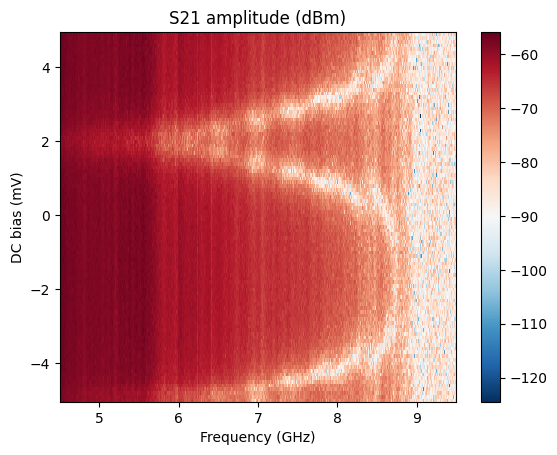

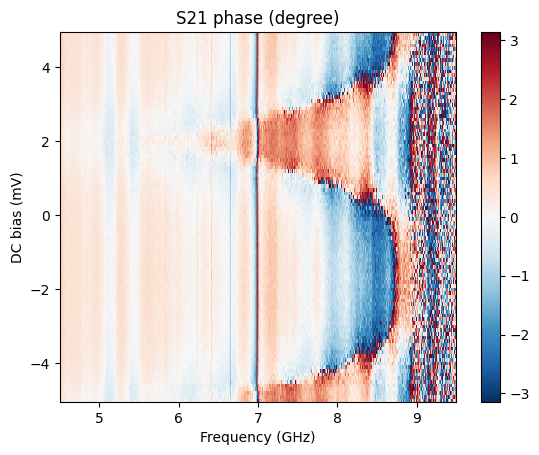

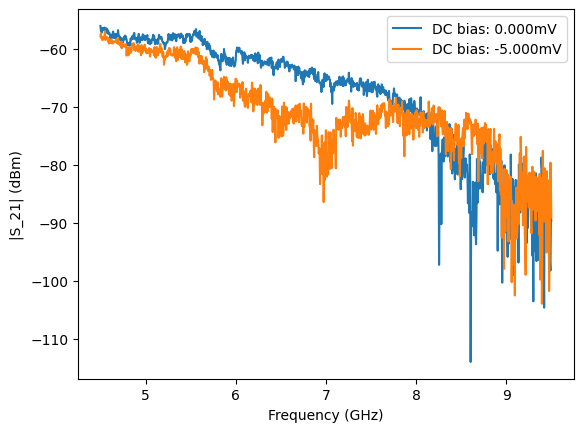

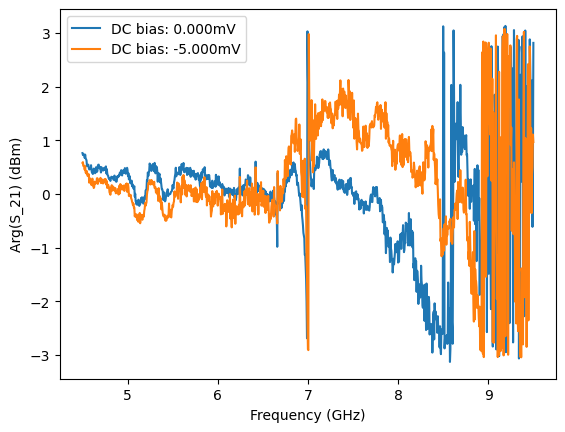

In [ ]:
%matplotlib inline
# dc_list=dc_list[10:-10]
data=[]
for i,dc in enumerate(dc_list):
    data.append(df2[i]["z"])
data=np.array(data)

# %matplotlib inline
plt.figure()
plt.pcolor( df2[0]["freq"]/1e9, dc_list*1e3, 20*np.log10(np.abs( data ) ), cmap="RdBu_r")
plt.colorbar()
plt.xlabel("Frequency (GHz)")
plt.ylabel("DC bias (mV)")
plt.title("S21 amplitude (dBm)")

plt.figure()
plt.pcolor( df2[0]["freq"]/1e9, dc_list*1e3,  (np.angle( data)) , cmap="RdBu_r" )
plt.colorbar()
plt.xlabel("Frequency (GHz)")
plt.ylabel("DC bias (mV)")
plt.title("S21 phase (degree)")


plt.figure()
idx=50
plt.plot( df2[0]["freq"]/1e9, 20*np.log10(np.abs( data[idx] ) ) ,label=f"DC bias: {dc_list[idx]*1e3:.3f}mV")
idx=0
plt.plot( df2[0]["freq"]/1e9, 20*np.log10(np.abs( data[idx] ) ) ,label=f"DC bias: {dc_list[idx]*1e3:.3f}mV")
plt.xlabel("Frequency (GHz)")
plt.ylabel("|S_21| (dBm)")
plt.legend()

plt.figure()
idx=50
plt.plot( df2[0]["freq"]/1e9, ((np.angle( data[idx] ) )) ,label=f"DC bias: {dc_list[idx]*1e3:.3f}mV")
idx=0
plt.plot( df2[0]["freq"]/1e9, ((np.angle( data[idx] ) )) ,label=f"DC bias: {dc_list[idx]*1e3:.3f}mV")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Arg(S_21) (dBm)")
plt.legend()

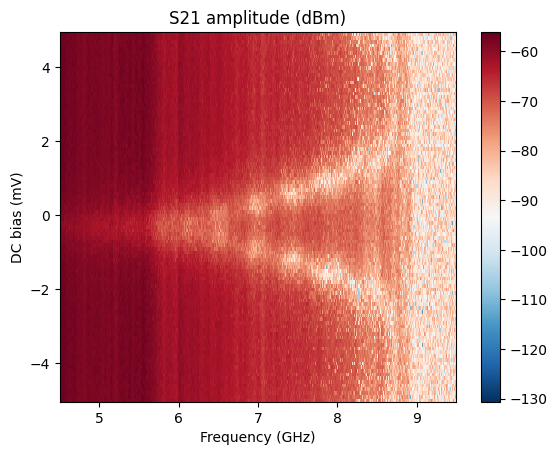

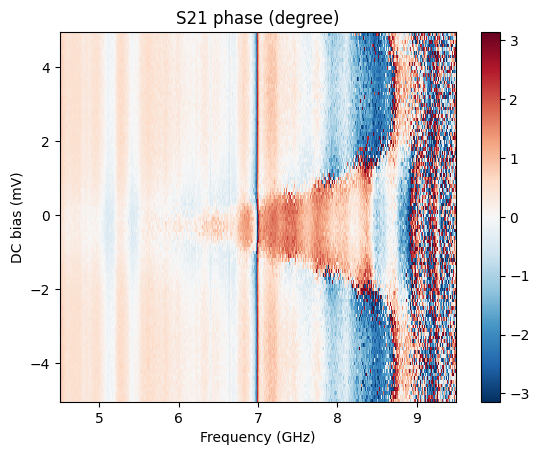

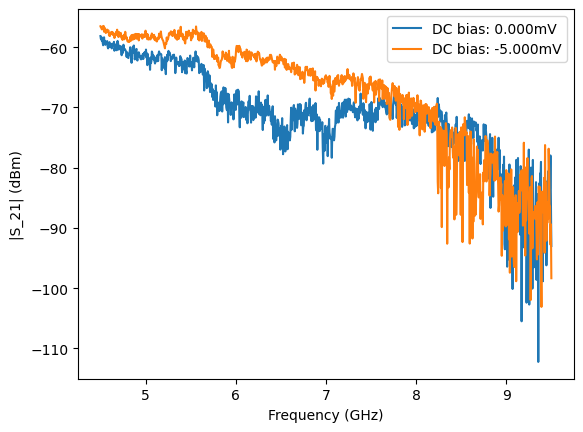

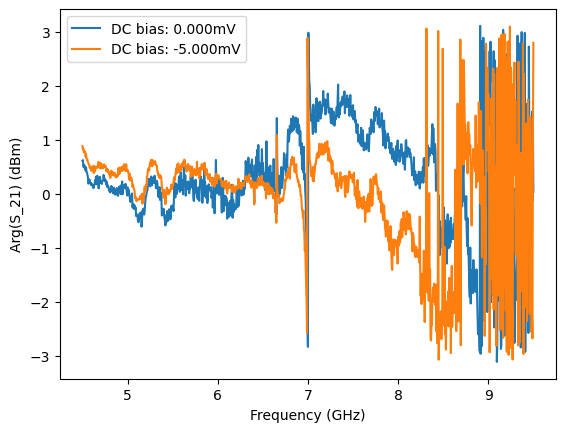

In [ ]:
%matplotlib inline
# dc_list=dc_list[10:-10]
data=[]
for i,dc in enumerate(dc_list):
    data.append(df2[i]["z"])
data=np.array(data)

# %matplotlib inline
plt.figure()
plt.pcolor( df2[0]["freq"]/1e9, dc_list*1e3, 20*np.log10(np.abs( data ) ), cmap="RdBu_r")
plt.colorbar()
plt.xlabel("Frequency (GHz)")
plt.ylabel("DC bias (mV)")
plt.title("S21 amplitude (dBm)")

plt.figure()
plt.pcolor( df2[0]["freq"]/1e9, dc_list*1e3,  (np.angle( data)) , cmap="RdBu_r" )
plt.colorbar()
plt.xlabel("Frequency (GHz)")
plt.ylabel("DC bias (mV)")
plt.title("S21 phase (degree)")


plt.figure()
idx=50
plt.plot( df2[0]["freq"]/1e9, 20*np.log10(np.abs( data[idx] ) ) ,label=f"DC bias: {dc_list[idx]*1e3:.3f}mV")
idx=0
plt.plot( df2[0]["freq"]/1e9, 20*np.log10(np.abs( data[idx] ) ) ,label=f"DC bias: {dc_list[idx]*1e3:.3f}mV")
plt.xlabel("Frequency (GHz)")
plt.ylabel("|S_21| (dBm)")
plt.legend()

plt.figure()
idx=50
plt.plot( df2[0]["freq"]/1e9, ((np.angle( data[idx] ) )) ,label=f"DC bias: {dc_list[idx]*1e3:.3f}mV")
idx=0
plt.plot( df2[0]["freq"]/1e9, ((np.angle( data[idx] ) )) ,label=f"DC bias: {dc_list[idx]*1e3:.3f}mV")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Arg(S_21) (dBm)")
plt.legend()

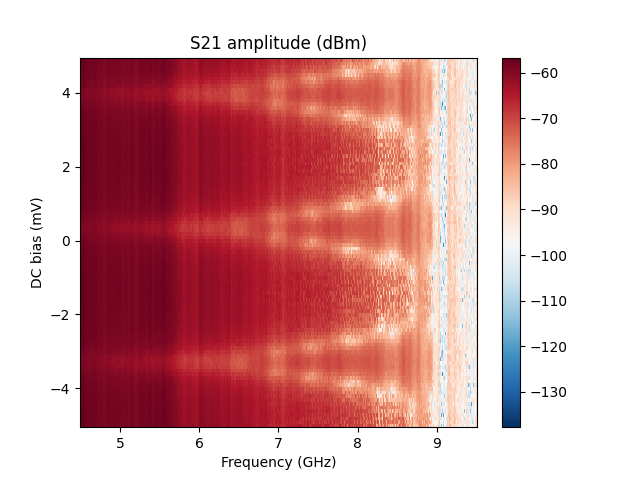

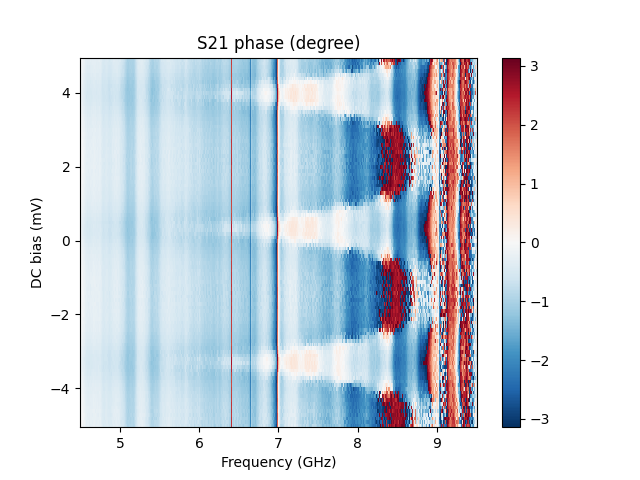

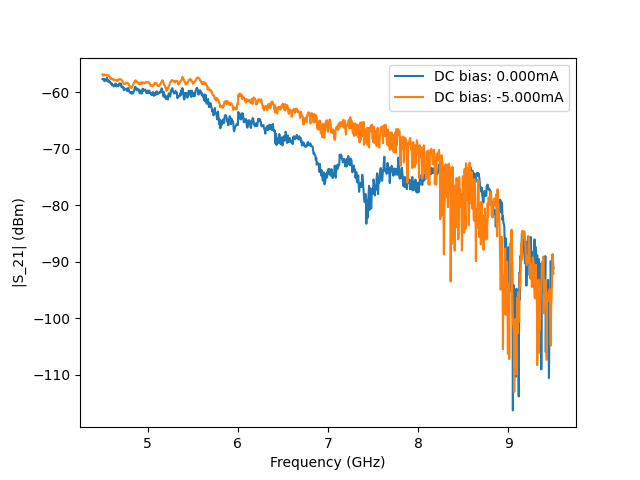

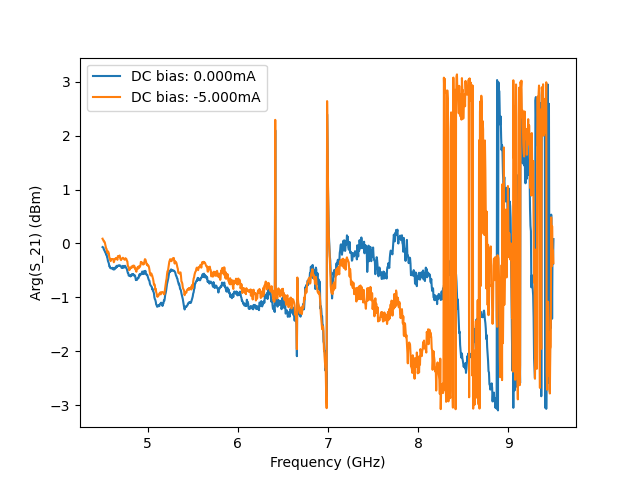

In [ ]:
%matplotlib widget
# dc_list=dc_list[10:-10]
data=[]
for i,dc in enumerate(dc_list):
    data.append(df2[i]["z"])
data=np.array(data)

# %matplotlib inline
plt.figure()
plt.pcolor( df2[0]["freq"]/1e9, dc_list*1e3, 20*np.log10(np.abs( data ) ), cmap="RdBu_r")
plt.colorbar()
plt.xlabel("Frequency (GHz)")
plt.ylabel("DC bias (mV)")
plt.title("S21 amplitude (dBm)")

plt.figure()
plt.pcolor( df2[0]["freq"]/1e9, dc_list*1e3,  (np.angle( data)) , cmap="RdBu_r" )
plt.colorbar()
plt.xlabel("Frequency (GHz)")
plt.ylabel("DC bias (mV)")
plt.title("S21 phase (degree)")


plt.figure()
idx=50
plt.plot( df2[0]["freq"]/1e9, 20*np.log10(np.abs( data[idx] ) ) ,label=f"DC bias: {dc_list[idx]*1e3:.3f}mA")
idx=0
plt.plot( df2[0]["freq"]/1e9, 20*np.log10(np.abs( data[idx] ) ) ,label=f"DC bias: {dc_list[idx]*1e3:.3f}mA")
plt.xlabel("Frequency (GHz)")
plt.ylabel("|S_21| (dBm)")
plt.legend()

plt.figure()
idx=50
plt.plot( df2[0]["freq"]/1e9, ((np.angle( data[idx] ) )) ,label=f"DC bias: {dc_list[idx]*1e3:.3f}mA")
idx=0
plt.plot( df2[0]["freq"]/1e9, ((np.angle( data[idx] ) )) ,label=f"DC bias: {dc_list[idx]*1e3:.3f}mA")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Arg(S_21) (dBm)")
plt.legend()

Text(0.5, 1.0, 'S21 phase (degree)')

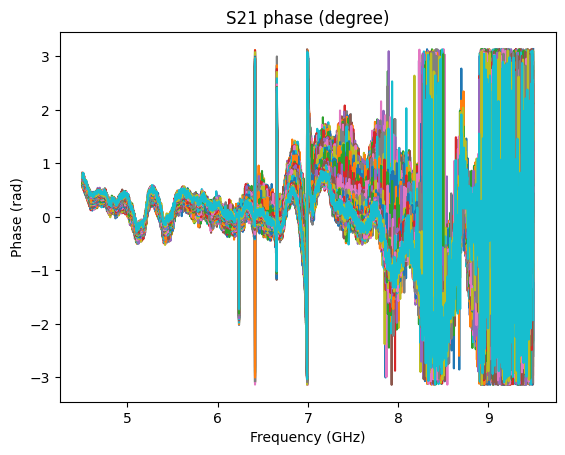

In [ ]:
data=[]
for i,dc in enumerate(dc_list):
    data.append(df2[i]["z"])
data=np.array(data)

plt.figure()
[plt.plot( df2[0]["freq"]/1e9,   (np.angle( i))  ) for i in data[:] ]
# plt.colorbar()
plt.xlabel("Frequency (GHz)")
plt.ylabel("Phase (rad)")
plt.title("S21 phase (degree)")

In [ ]:
df2=[]
# lev=-12e-3

lev = -18e-3
dc_stop = -12e-3
step_size = 2e-4
dc_list =np.arange(lev,dc_stop, step_size)

small_step = 1e-5

# small_step = 1e-5
for dc in dc_list:
    df2.append(pd.read_csv(f'Z:\\MW measurement\\20251016_cooldown\\VNA_data\\JPA_DC_sweep_20251018\\JPA_freq_vs_dcbias_{dc*1E3:.3f}mA_B_93d5mT_curr_mode_-130dBm_2000pts_wo_LPF.csv', dtype={'freq':'float64'}, converters={'z':lambda x:complex(x.replace('i', 'j'))}))

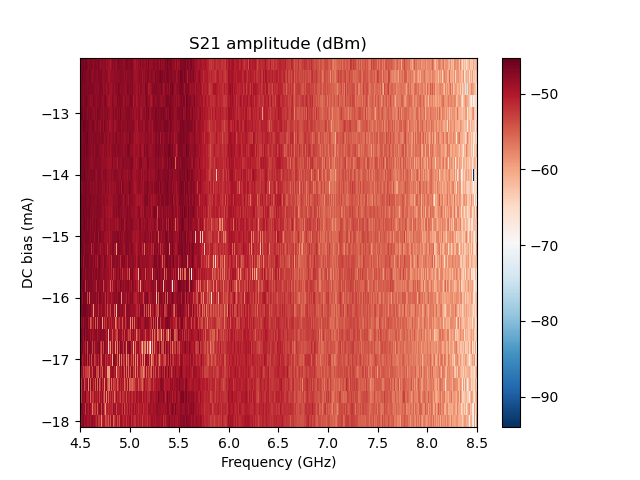

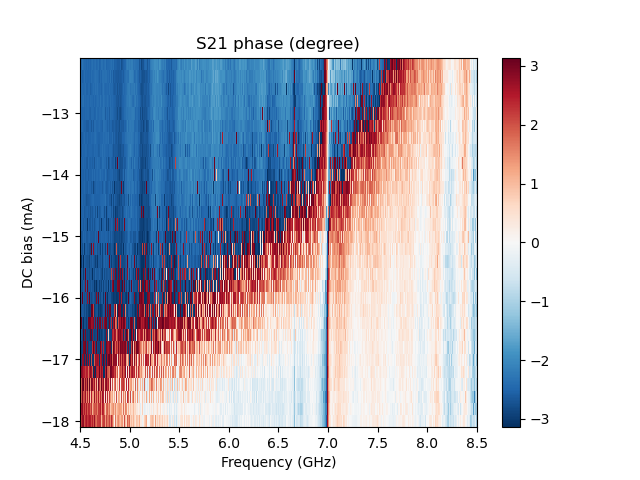

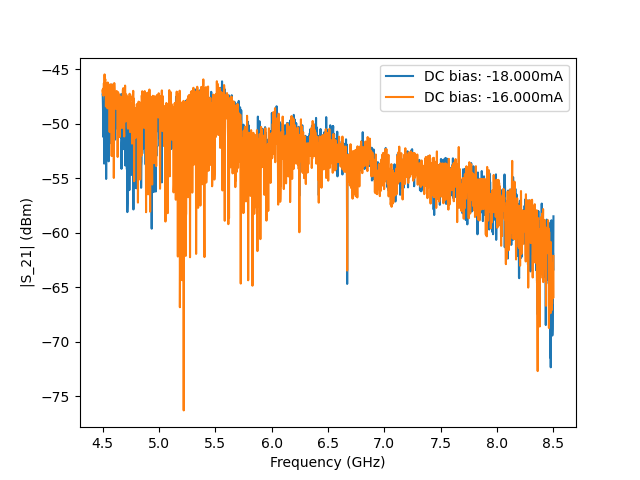

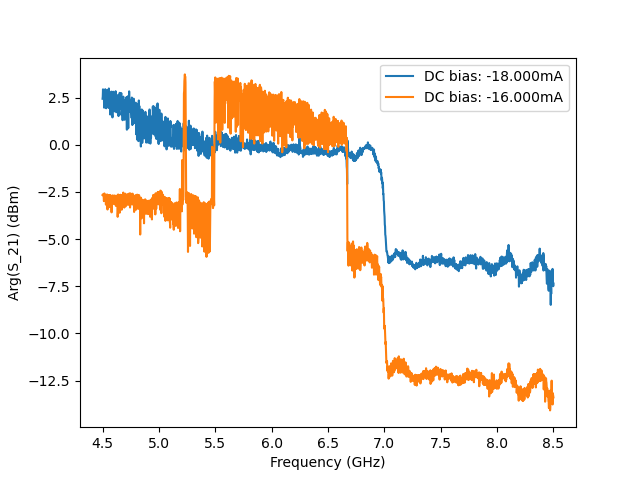

In [ ]:
%matplotlib widget
data=[]
for i,dc in enumerate(dc_list):
    data.append(df2[i]["z"])
data=np.array(data)

# %matplotlib inline
plt.figure()
plt.pcolor( df2[0]["freq"]/1e9, dc_list*1e3, 20*np.log10(np.abs( data ) ), cmap="RdBu_r")
plt.colorbar()
plt.xlabel("Frequency (GHz)")
plt.ylabel("DC bias (mA)")
plt.title("S21 amplitude (dBm)")

plt.figure()
plt.pcolor( df2[0]["freq"]/1e9, dc_list*1e3,  (np.angle( data)) , cmap="RdBu_r" )
plt.colorbar()
plt.xlabel("Frequency (GHz)")
plt.ylabel("DC bias (mA)")
plt.title("S21 phase (degree)")


plt.figure()
idx=0
plt.plot( df2[0]["freq"]/1e9, 20*np.log10(np.abs( data[idx] ) ) ,label=f"DC bias: {dc_list[idx]*1e3:.3f}mA")
idx=10
plt.plot( df2[0]["freq"]/1e9, 20*np.log10(np.abs( data[idx] ) ) ,label=f"DC bias: {dc_list[idx]*1e3:.3f}mA")
plt.xlabel("Frequency (GHz)")
plt.ylabel("|S_21| (dBm)")
plt.legend()

plt.figure()
idx=0
plt.plot( df2[0]["freq"]/1e9, np.unwrap((np.angle( data[idx] ) )) ,label=f"DC bias: {dc_list[idx]*1e3:.3f}mA")
idx=10
plt.plot( df2[0]["freq"]/1e9, np.unwrap((np.angle( data[idx] ) )) ,label=f"DC bias: {dc_list[idx]*1e3:.3f}mA")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Arg(S_21) (dBm)")
plt.legend()

# B sweep

In [ ]:
B_arr = np.arange(0.080, 0.120, 0.0005)
B_arr.shape

(80,)

In [ ]:
import time
res_lst = []

# B_arr = np.arange(0.080, 0.120, 0.0005)
B0 = 0 # Unit is Tesla.

xi = np.pi/6 # pi/6 best for metal.
# xi = 0.0
phi0 = -0.009749409201640323#0.0044820
psi0 = -0.0003825761720371579#-0.0051718

# ramp(0,rate=0.001, xi=xi,phi =phi0,psi=psi0)

In [ ]:
print(f"B0: {B0}")
ramp(B0, rate=0.0003, xi=xi, phi=phi0, psi=psi0, Max_B=[1, 1, 1])

B0: 0
Ramping to 0.000 mT along the specified direction.
Sleeping for : 1333.33 seconds


In [ ]:
import time
res_lst = []

center_freqs = [6.5e9]#[6.666e9]

span_freq = 4e9

B_arr = np.arange(0.0, 0.40, 0.002)
B0 = B_arr[0]

xi = np.pi/6
phi0 = -0.009749409201640323#0.0044820
psi0 = -0.0003825761720371579#-0.0051718

for i,B0 in enumerate(B_arr[:]):
    ramp(B0, rate=0.0001, xi=xi,phi =phi0,psi=psi0, step=11, Max_B=[0.5,0.5,0.1], heating_time = 30, epsilon=1e-6)
    time.sleep(2)
    df = read_trace(sleep_time=3,center_freq = center_freqs[0], span_freq=span_freq)
    
    df.to_csv(f'VNA_data\\Bsweep_20251107\\B0_{B0*1e3:.3f}_power_-120dBm_DC0d28mA.csv')

    if i%20 == 0:
        print(f'{xi*180/np.pi:.1f}  {B0*1e3:.1f}')


Ramping to 0.000 mT along the specified direction.
Sleeping for : 980.07 seconds
30.0  0.0
Ramping to 2.000 mT along the specified direction.
Sleeping for : 20.03 seconds
Ramping to 4.000 mT along the specified direction.
Sleeping for : 19.96 seconds
Ramping to 6.000 mT along the specified direction.
Sleeping for : 20.02 seconds
Ramping to 8.000 mT along the specified direction.
Sleeping for : 20.06 seconds
Ramping to 10.000 mT along the specified direction.
Sleeping for : 19.98 seconds
Ramping to 12.000 mT along the specified direction.
Sleeping for : 20.03 seconds
Ramping to 14.000 mT along the specified direction.
Sleeping for : 19.99 seconds
Ramping to 16.000 mT along the specified direction.
Sleeping for : 20.03 seconds
Ramping to 18.000 mT along the specified direction.
Sleeping for : 19.90 seconds
Ramping to 20.000 mT along the specified direction.
Sleeping for : 20.06 seconds
Ramping to 22.000 mT along the specified direction.
Sleeping for : 20.00 seconds
Ramping to 24.000 mT a

In [ ]:
import time

# B_arr = np.arange(0.080, 0.120, 0.0005)
B0 = 0.0935

xi = np.pi/6
phi0 = 0.0044820
psi0 = -0.0051718

# ramp(0,rate=0.001, xi=xi,phi =phi0,psi=psi0)
ramp(B0, rate=0.0002, xi=xi,phi =phi0,psi=psi0,Max_B=[0.5,0.5,1])

Ramping to 93.500 mT along the specified direction.
Sleeping for : 129.98 seconds


In [ ]:
df2=[]

B_arr = np.arange(0.00, 0.10, 0.002)
B0 = B_arr[0]

xi = np.pi/6
# phi0 = 0.0044820
# psi0 = -0.0051718

for B0 in B_arr:
    df2.append(pd.read_csv(f'VNA_data\\Bsweep_20251107\\B0_{B0*1e3:.3f}_power_-120dBm_1.csv', dtype={'freq':'float64'}, converters={'z':lambda x:complex(x.replace('i', 'j'))}))

Text(0.5, 1.0, 'S21 phase (radian)')

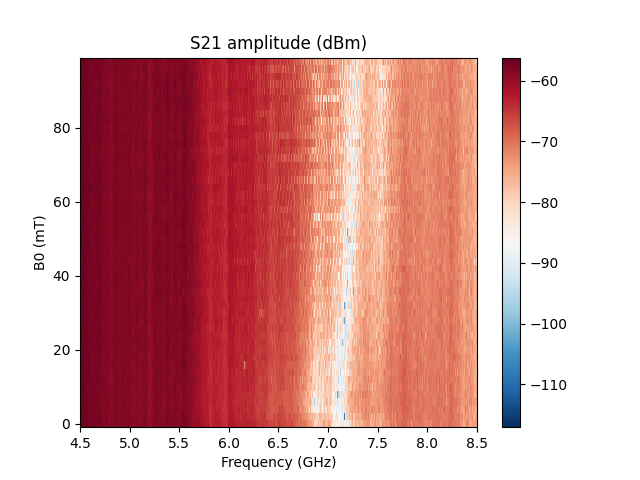

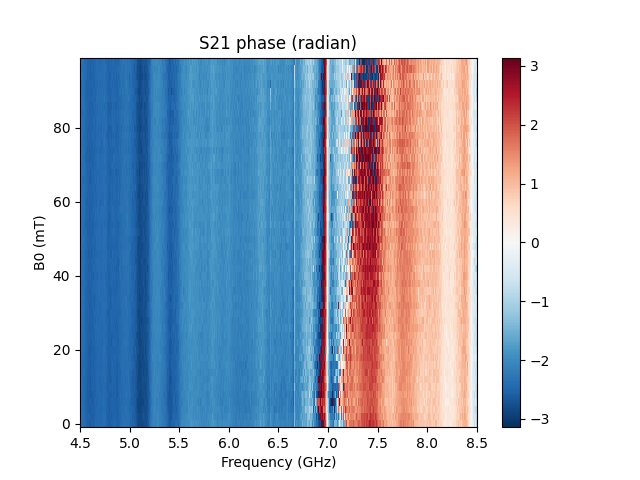

In [ ]:
%matplotlib widget
data=[]
for i,_ in enumerate(B_arr):
    data.append(df2[i]["z"])
data=np.array(data)

# %matplotlib inline
plt.figure()
plt.pcolor( df2[0]["freq"]/1e9, B_arr*1e3, 20*np.log10(np.abs( data ) ), cmap="RdBu_r")
plt.colorbar()
plt.xlabel("Frequency (GHz)")
plt.ylabel("B0 (mT)")
plt.title("S21 amplitude (dBm)")

plt.figure()
plt.pcolor( df2[0]["freq"]/1e9, B_arr*1e3,  np.angle( data ) , cmap="RdBu_r" )
plt.colorbar()
plt.xlabel("Frequency (GHz)")
plt.ylabel("B0 (mT)")
plt.title("S21 phase (radian)")